In [15]:
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sn 
import warnings 
warnings.filterwarnings('ignore')

In [16]:
df = pd.read_csv('expenses.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [17]:
df.shape

(1338, 7)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [19]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [20]:
df_float = df.select_dtypes(include= 'float').columns 
print(df_float)

Index(['bmi', 'charges'], dtype='object')


In [21]:
# Target -> smoker -> classification -> cla"ss imbalance -> SMOTE

<Axes: xlabel='smoker', ylabel='count'>

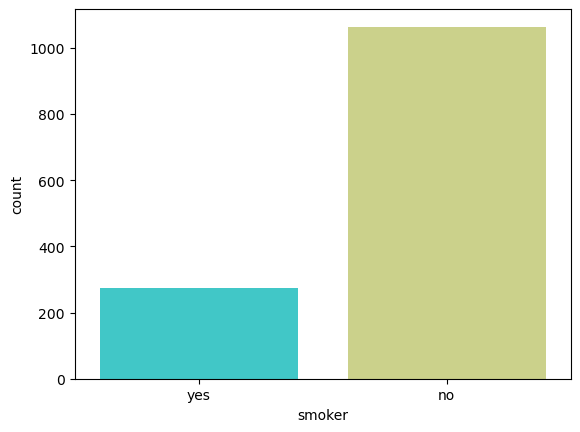

In [22]:
sn.countplot(x = df['smoker'], palette='rainbow')

In [23]:
cat_cols = df.select_dtypes(include= 'object').columns.tolist()
cat_cols.remove('smoker')

In [24]:
df = pd.get_dummies(df, columns=cat_cols)
df['smoker'] = df['smoker'].map({'yes' : 1 , 'no' : 0})

In [26]:
X = df.drop('smoker', axis = 1)
y = df['smoker']

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score , confusion_matrix

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [32]:
Gradient_model = GradientBoostingClassifier()

In [34]:
Gradient_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [37]:
y_pred = Gradient_model.predict(X_test)
y_pred

array([0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,

In [39]:
accuracy = accuracy_score(y_test , y_pred)
accuracy

0.9638009049773756

<Axes: >

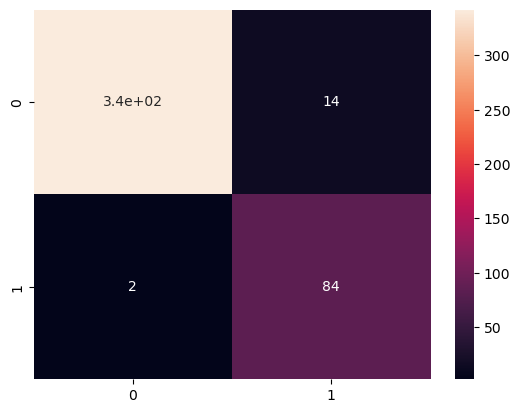

In [42]:
sn.heatmap(confusion_matrix(y_test, y_pred), annot=True)

# Assistant
This error occurs because there's a typo in one of the parameter names in your `param_grid`. The error message indicates that `'max_deapth'` is not a valid parameter - it should be `'max_depth'` (you're missing the 't' in 'depth').

The `GradientBoostingClassifier` doesn't recognize `'max_deapth'` as a valid parameter. Looking at the error message, you can see that `'max_depth'` is listed among the valid parameters.

Would you like me to provide the corrected code?

# User
params grid fix it

In [50]:
# Assistant
# Corrected param_grid with proper spelling
param_grid = {
    'max_depth': [3, 5, 7, 9],  # Fixed: was 'max_deapth', now 'max_depth'
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 4]
}

from sklearn.model_selection import RandomizedSearchCV

random_model = RandomizedSearchCV(
    estimator= GradientBoostingClassifier(), 
    param_distributions= param_grid,  # Now uses corrected param_grid
    n_iter=10 ,  
    cv = 5, 
    verbose= 2, 
    n_jobs=-1
)
random_model_result = random_model.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
